<h2 style="color:blue" align="center">Tensorboard demo using handwritten digits classification using neural network</h2>

In this notebook we will classify handwritten digits using a simple neural network which has only input and output layers. We will than add a hidden layer and see how the performance of the model improves

Below program is the same one which we did in 1st session"Digit Recognition". We are just adding extra instruction/code
while invoking the model to enable the tensorboard also.

In [17]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [18]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [19]:
len(X_train)

60000

In [20]:
len(X_test)

10000

In [21]:
X_train[0].shape

(28, 28)

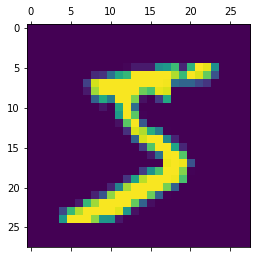

In [22]:
plt.matshow(X_train[0])

In [23]:
y_train[0]

5

In [24]:
X_train = X_train / 255
X_test = X_test / 255

In [25]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [26]:
X_train_flattened.shape

(60000, 784)

<h3 style='color:purple'>Using Flatten layer so that we don't have to call .reshape on input dataset</h3>

In [27]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/adam", histogram_freq=1) 
# this is the extra code we have added to enable logging which can be viewed via Tensorboard. 

# During fit, we are using this callbacks=[tb_callback], so this function will store all loss and accuracy info in log_dir="logs/adam" folder
model.fit(X_train, y_train, epochs=5, callbacks=[tb_callback])

Epoch 1/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.2747 - accuracy: 0.9223
Epoch 2/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1242 - accuracy: 0.9630
Epoch 3/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0871 - accuracy: 0.9733
Epoch 4/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0651 - accuracy: 0.9803 0s - loss: 0.0650 - accuracy: 0.
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0513 - accuracy: 0.9844


## APPLY TENSORBOARD BELOW

In [28]:
%load_ext tensorboard
%tensorboard --logdir logs/adam/train
#%tensorboard --logdir logs/fit


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 40088), started 4:02:07 ago. (Use '!kill 40088' to kill it.)

Either run above inline magic or go to git bash or your command prompt and type below to run it,
`tensorboard --logdir logs/`
This will launch tensorboard at this url which you can open in your browser `http://localhost:6006/`

In [29]:
model.get_weights()

[array([[ 3.1831361e-02, -5.3987540e-02, -8.0430627e-02, ...,
          7.7918246e-02,  3.0028053e-02, -5.4419726e-02],
        [-6.1180823e-02,  7.0316792e-02,  3.5600796e-02, ...,
          1.8473372e-02, -3.9442725e-02,  3.0482791e-02],
        [ 1.7409511e-02,  2.4005771e-05,  4.1094571e-02, ...,
          9.1697946e-03, -5.6927212e-02, -5.1782157e-02],
        ...,
        [-2.7780794e-02,  7.0944339e-02,  5.4786354e-03, ...,
          6.7399845e-02,  7.6610699e-02,  1.2907565e-02],
        [ 3.4561723e-02,  9.8852813e-03, -1.0578349e-02, ...,
          1.5195161e-03, -1.7331883e-02,  7.3889568e-02],
        [-7.6656751e-02, -4.5337502e-02,  6.0918674e-02, ...,
         -2.2449162e-02, -2.8780639e-02, -6.5693319e-02]], dtype=float32),
 array([-5.89292571e-02, -2.71008292e-04,  1.48401281e-03,  3.55308168e-02,
         4.09050547e-02,  8.70151594e-02, -2.29759831e-02,  7.98463002e-02,
         1.96217403e-01,  2.28898510e-01, -3.38569283e-02, -2.50948183e-02,
        -1.84762962e-0

In [30]:
# Now Lets use SGD optimizer

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/sgd", histogram_freq=1) #note, here we are storing log in different folder.
# this is the extra code we have added to enable logging which can be viewed via Tensorboard. 

model.fit(X_train, y_train, epochs=5, callbacks=[tb_callback])

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.6560 - accuracy: 0.8349
Epoch 2/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3418 - accuracy: 0.9038
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2938 - accuracy: 0.9173
Epoch 4/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2642 - accuracy: 0.9261
Epoch 5/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2420 - accuracy: 0.9327


In [31]:
%load_ext tensorboard
%tensorboard --logdir logs/sgd/train
#%tensorboard --logdir logs/fit

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 48544), started 3:18:31 ago. (Use '!kill 48544' to kill it.)

In [32]:
# Now to compare 2 models we are invoking log folder. 

%load_ext tensorboard
%tensorboard --logdir logs
#%tensorboard --logdir logs/fit


#below we can easily understand that adam optimizer has performed good in getting both high accuracy and low loss. 

# Tensorboard is awesome !!!

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 45788), started 3:17:59 ago. (Use '!kill 45788' to kill it.)